# DiCE in Python - with the example of GSE239282

Based on this [Paper](https://doi.org/10.1093/nar/gkaf609). Since the paper divides the DiCE workflow into 6 Steps according to roman numerals, this example workflow will also be divided in these steps to show the progress.

Example Dataset: [GSE239282](https://www.ncbi.nlm.nih.gov/geo/geo2r/?acc=GSE239282) from GEO
- Age-related cognitive disorders (ACD) vs. controls
- Effects of music on their brains
- Only select ones with Timepoint 2 to remove duplicate accessions
- 48 total accessions, out of which 21 are control and 27 are ACD patients


In [1]:
import pandas as pd
import requests
import os

## Phase I: construction of gene candidate pool by DEA

### Step I.1: Download raw data from the [GEO Page on NCBI](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE239282) 
- Get both the normalized corrected expression for ACD and the Controls (`GSE239282_Norm_corrected_exp_ACD.txt.gz` and `GSE239282_Norm_corrected_exp_CONTROLS.txt.gz`)
- Place them in the `data` folder

Unzip the files first and load them into Pandas Dataframes

In [2]:
acd_file = os.path.join("..", "data", "GSE239282_Norm_corrected_exp_ACD.txt.gz")

acd_df =  pd.read_csv(acd_file, compression="gzip", sep=" ")

print(acd_df.shape)
acd_df.head()

(36155, 32)


,22_P_1003_1_t,22_P_1003_2_t,22_P_1006_1_t,22_P_1006_2_t,22_P_1009_1_t,22_P_1009_2_t,22_P_1052_1_t,22_P_1052_2_t,22_P_1055_1_t,22_P_1055_2_t,...,22_P_1137_1_t,22_P_1137_2_t,22_P_1139_1_t,22_P_1139_2_t,22_P_1144_1_t,22_P_1144_2_t,22_P_1145_1_t,22_P_1145_2_t,22_P_1149_1_t,22_P_1149_2_t
ENSG00000186827,8.610525,8.504742,8.589072,8.526195,8.595409,8.519858,8.432430,8.682836,8.587906,8.527360,...,8.562600,8.552666,8.712604,8.402663,8.609995,8.505272,8.584278,8.530989,8.341124,8.774143
ENSG00000186891,7.828481,8.016035,7.945485,7.899031,8.053736,7.790780,7.963202,7.881314,7.945408,7.899108,...,7.928480,7.916036,8.097148,7.747368,8.014888,7.829628,8.086238,7.758278,7.720037,8.124479
ENSG00000160072,7.836021,8.299189,8.035940,8.099270,8.174804,7.960406,7.895770,8.239440,8.020948,8.114262,...,8.146242,7.988968,8.298583,7.836627,8.202834,7.932376,8.145979,7.989231,8.003293,8.131917
ENSG00000041988,8.849681,9.008522,9.072159,8.786044,8.866810,8.991393,8.923828,8.934375,8.902255,8.955948,...,9.017802,8.840402,8.983226,8.874977,8.888825,8.969379,9.016611,8.841592,8.708116,9.150087
ENSG00000260179,6.503095,6.302982,6.531647,6.274430,6.321415,6.484662,6.401950,6.404127,6.334870,6.471207,...,6.291718,6.514359,6.621007,6.185070,6.403039,6.403039,6.403039,6.403039,6.403039,6.403039


In [3]:
control_file = os.path.join("..", "data", "GSE239282_Norm_corrected_exp_CONTROLS.txt.gz")
control_df = pd.read_csv(control_file, compression="gzip", sep=" ")

print(control_df.shape)

control_df.head()

(35865, 28)


,22_P_1001_1_M,22_P_1001_2_M,22_P_1004_1_M,22_P_1004_2_M,22_P_1013_1_t,22_P_1013_2_t,22_P_1020_1_t,22_P_1020_2_t,22_P_1021_1_t,22_P_1021_2_t,...,22_P_1065_1_t,22_P_1065_2_t,22_P_1069_1_t,22_P_1069_2_t,22_P_1079_1_t,22_P_1079_2_t,22_P_1103_1_t,22_P_1103_2_t,22_P_1120_1_t,22_P_1120_2_t
ENSG00000186827,8.883350,8.662983,8.635358,8.910976,8.731457,8.814876,8.818804,8.727529,8.561679,8.984654,...,8.786965,8.759369,8.976178,8.570156,8.791217,8.755116,8.896566,8.649768,8.598246,8.948087
ENSG00000186891,7.939168,7.999012,7.840740,8.097440,7.996373,7.941807,8.025952,7.912229,7.911350,8.026830,...,8.115303,7.822877,8.056440,7.881741,7.968946,7.969235,8.127619,7.810561,7.953573,7.984608
ENSG00000160072,8.389852,8.293670,8.049834,8.633688,8.372360,8.311163,8.481011,8.202511,8.040505,8.643017,...,8.461966,8.221556,8.325660,8.357862,8.445201,8.238321,8.504728,8.178794,8.169602,8.513920
ENSG00000041988,8.992454,9.223743,9.076469,9.139728,9.123871,9.092325,9.035888,9.180309,9.211157,9.005039,...,9.150607,9.065590,9.123860,9.092337,9.150915,9.065282,9.209681,9.006515,8.992529,9.223668
ENSG00000260179,6.477273,6.287379,6.382326,6.382326,6.501114,6.263538,6.489025,6.275627,6.382326,6.382326,...,6.453567,6.311084,6.382326,6.382326,6.478669,6.285982,6.382326,6.382326,6.521689,6.242963


Curious thing about this dataset: Sometimes, accessions are double - once at timepoint 1 (before treatment with music), and once at timepoint 2 (after treatment with music)

To account for this and make sure we don't count single individuals twice, we have to remove all patients/samples that have "_1_M" or "_1_t" in their name. 

This should halve the number of rows since there is always one measurement at timepoint 1 and one at timepoint 2.

In [4]:
print(f"ACD Columns before filtering: {len(acd_df.columns)} Columns, all columns: {list(acd_df.columns)}")
acd_timepoint2_columns = [column for column in acd_df if not "_1_t" in str(column) and not "_1_M" in str(column)]
print(f"ACD Columns after filtering: {len(acd_timepoint2_columns)} Columns, all columns: {acd_timepoint2_columns}")

print(f"Control Columns before filtering: {len(control_df.columns)} Columns, all columns: {list(control_df.columns)}")
control_timepoint2_columns = [column for column in control_df if not "_1_t" in str(column) and not "_1_M" in str(column)]
print(f"Control Columns after filtering: {len(control_timepoint2_columns)} Columns, all columns: {control_timepoint2_columns}")


ACD Columns before filtering: 32 Columns, all columns: ['22_P_1003_1_t', '22_P_1003_2_t', '22_P_1006_1_t', '22_P_1006_2_t', '22_P_1009_1_t', '22_P_1009_2_t', '22_P_1052_1_t', '22_P_1052_2_t', '22_P_1055_1_t', '22_P_1055_2_t', '22_P_1066_1_t', '22_P_1066_2_t', '22_P_1081_1_t', '22_P_1081_2_t', '22_P_1111_1_t', '22_P_1111_2_t', '22_P_1119_1_t', '22_P_1119_2_t', '22_P_1132_1_t', '22_P_1132_2_t', '22_P_1134_1_t', '22_P_1134_2_t', '22_P_1137_1_t', '22_P_1137_2_t', '22_P_1139_1_t', '22_P_1139_2_t', '22_P_1144_1_t', '22_P_1144_2_t', '22_P_1145_1_t', '22_P_1145_2_t', '22_P_1149_1_t', '22_P_1149_2_t']
ACD Columns after filtering: 16 Columns, all columns: ['22_P_1003_2_t', '22_P_1006_2_t', '22_P_1009_2_t', '22_P_1052_2_t', '22_P_1055_2_t', '22_P_1066_2_t', '22_P_1081_2_t', '22_P_1111_2_t', '22_P_1119_2_t', '22_P_1132_2_t', '22_P_1134_2_t', '22_P_1137_2_t', '22_P_1139_2_t', '22_P_1144_2_t', '22_P_1145_2_t', '22_P_1149_2_t']
Control Columns before filtering: 28 Columns, all columns: ['22_P_1001_1_

In [5]:
acd_df = acd_df[acd_timepoint2_columns]
print(acd_df.shape)
acd_df.head()

(36155, 16)


,22_P_1003_2_t,22_P_1006_2_t,22_P_1009_2_t,22_P_1052_2_t,22_P_1055_2_t,22_P_1066_2_t,22_P_1081_2_t,22_P_1111_2_t,22_P_1119_2_t,22_P_1132_2_t,22_P_1134_2_t,22_P_1137_2_t,22_P_1139_2_t,22_P_1144_2_t,22_P_1145_2_t,22_P_1149_2_t
ENSG00000186827,8.504742,8.526195,8.519858,8.682836,8.527360,8.574406,8.542985,8.331633,8.551066,8.468595,8.614118,8.552666,8.402663,8.505272,8.530989,8.774143
ENSG00000186891,8.016035,7.899031,7.790780,7.881314,7.899108,7.732916,7.749307,7.828268,7.922400,7.648196,8.019141,7.916036,7.747368,7.829628,7.758278,8.124479
ENSG00000160072,8.299189,8.099270,7.960406,8.239440,8.114262,7.934136,8.009329,7.869653,7.873457,7.917407,8.126334,7.988968,7.836627,7.932376,7.989231,8.131917
ENSG00000041988,9.008522,8.786044,8.991393,8.934375,8.955948,8.855553,8.882743,8.890947,8.949587,8.801069,8.966777,8.840402,8.874977,8.969379,8.841592,9.150087
ENSG00000260179,6.302982,6.274430,6.484662,6.404127,6.471207,6.403039,6.403039,6.475797,6.403039,6.403039,6.403039,6.514359,6.185070,6.403039,6.403039,6.403039


In [6]:
control_df = control_df[control_timepoint2_columns]
print(control_df.shape)
control_df.head()

(35865, 14)


,22_P_1001_2_M,22_P_1004_2_M,22_P_1013_2_t,22_P_1020_2_t,22_P_1021_2_t,22_P_1022_2_t,22_P_1056_2_t,22_P_1060_2_t,22_P_1062_2_t,22_P_1065_2_t,22_P_1069_2_t,22_P_1079_2_t,22_P_1103_2_t,22_P_1120_2_t
ENSG00000186827,8.662983,8.910976,8.814876,8.727529,8.984654,8.917620,8.792564,8.980667,8.785049,8.759369,8.570156,8.755116,8.649768,8.948087
ENSG00000186891,7.999012,8.097440,7.941807,7.912229,8.026830,8.023756,7.955509,8.093469,7.964896,7.822877,7.881741,7.969235,7.810561,7.984608
ENSG00000160072,8.293670,8.633688,8.311163,8.202511,8.643017,8.488877,8.382109,8.386469,8.233644,8.221556,8.357862,8.238321,8.178794,8.513920
ENSG00000041988,9.223743,9.139728,9.092325,9.180309,9.005039,9.165657,9.113144,9.118238,8.993156,9.065590,9.092337,9.065282,9.006515,9.223668
ENSG00000260179,6.287379,6.382326,6.263538,6.275627,6.382326,6.186864,6.230492,6.382326,6.382326,6.311084,6.382326,6.285982,6.382326,6.242963


Combine the two Dataframes into one

In [7]:
raw_data_df = pd.concat(objs=[acd_df, control_df], axis=1)
print(raw_data_df.shape)
raw_data_df.head()

(38327, 30)


,22_P_1003_2_t,22_P_1006_2_t,22_P_1009_2_t,22_P_1052_2_t,22_P_1055_2_t,22_P_1066_2_t,22_P_1081_2_t,22_P_1111_2_t,22_P_1119_2_t,22_P_1132_2_t,...,22_P_1021_2_t,22_P_1022_2_t,22_P_1056_2_t,22_P_1060_2_t,22_P_1062_2_t,22_P_1065_2_t,22_P_1069_2_t,22_P_1079_2_t,22_P_1103_2_t,22_P_1120_2_t
ENSG00000186827,8.504742,8.526195,8.519858,8.682836,8.527360,8.574406,8.542985,8.331633,8.551066,8.468595,...,8.984654,8.917620,8.792564,8.980667,8.785049,8.759369,8.570156,8.755116,8.649768,8.948087
ENSG00000186891,8.016035,7.899031,7.790780,7.881314,7.899108,7.732916,7.749307,7.828268,7.922400,7.648196,...,8.026830,8.023756,7.955509,8.093469,7.964896,7.822877,7.881741,7.969235,7.810561,7.984608
ENSG00000160072,8.299189,8.099270,7.960406,8.239440,8.114262,7.934136,8.009329,7.869653,7.873457,7.917407,...,8.643017,8.488877,8.382109,8.386469,8.233644,8.221556,8.357862,8.238321,8.178794,8.513920
ENSG00000041988,9.008522,8.786044,8.991393,8.934375,8.955948,8.855553,8.882743,8.890947,8.949587,8.801069,...,9.005039,9.165657,9.113144,9.118238,8.993156,9.065590,9.092337,9.065282,9.006515,9.223668
ENSG00000260179,6.302982,6.274430,6.484662,6.404127,6.471207,6.403039,6.403039,6.475797,6.403039,6.403039,...,6.382326,6.186864,6.230492,6.382326,6.382326,6.311084,6.382326,6.285982,6.382326,6.242963


### Step I.2: Perform DEA via GEO2R and filter for the resulting genes

The first part of the DiCE workflow, the construction of a gene candidate pool by DEA (Differential Expression Analysis) is done by GEO's GEO2R tool, available on the NCBI website.

- Go to the [GEO2R Page](https://www.ncbi.nlm.nih.gov/geo/geo2r/?acc=GSE239282) of this dataset
- Define two Groups based on the "Group" column: Control and ACD
- Assign all Control samples to the Control group and all ACD samples to the ACD group
  - You can already filter for timepoint 2 samples here, but it shouldn't make much of a difference overall
- (Optional for visualization) Go to Options below and set Significance level cut-off to 0
- Click "Analyze" or "Reanalyze" to run the GEO2R analysis
- Download the resulting table and put it into the `data` folder

We can then load the resulting table into a Pandas Dataframe

In [8]:
dea_file = os.path.join("..", "data", "GSE239282.top.table.tsv")
dea_results = pd.read_csv(filepath_or_buffer=dea_file, sep="\t")
print(dea_results.shape)
dea_results.head()

(16951, 9)


,GeneID,padj,pvalue,lfcSE,stat,log2FoldChange,baseMean,Symbol,Description
0,57124,5.730000e-14,3.380000e-18,0.3454,8.697919,3.004641,36.9,CD248,CD248 molecule
1,65982,1.060000e-13,1.250000e-17,0.1150,8.547813,0.982718,289.0,ZSCAN18,zinc finger and SCAN domain containing 18
2,107985900,3.560000e-13,6.300000e-17,0.2731,8.359392,2.283152,31.2,LOC107985900,uncharacterized LOC107985900
3,3983,4.600000e-12,1.090000e-15,0.1197,8.016679,0.959828,1180.0,ABLIM1,actin binding LIM protein 1
4,107985055,9.270000e-12,2.730000e-15,0.2245,-7.902487,-1.774106,23.1,LOC107985055,uncharacterized LOC107985055


Right now, this table is sorted by `padj`, the adjusted p-value. We want to only include those with a p-value of < 0.05 and, optionally, with a `log2FoldChange` of > 0.5.

In [9]:
from python_dice.preparation import filter_dea_table

dea_filtered_results = filter_dea_table(dea_results)

Now, we filter the entire DF to only keep genes that are mentioned in the filtered DEA table

Since this is a "weird" database, the gene IDs of the raw data and the GEO2R analysis results do NOT match. Instead, the raw data has Ensembl IDs (like `ENSG00000174807`), while the GEO2R DEA results have the NCBI gene ID (e.g. `57124`)

To map these names, we will download a mapping file from HGNC between HGNC ID, Ensembl ID and NCBI Gene ID, as well as Approved Symbol (will be used in Phase III) using the [custom downloads](https://www.genenames.org/download/custom/) page.

Below, we download the file if it doesn't exist yet.

In [10]:
from python_dice.preparation import get_gene_id_mappings

gene_id_mappings = get_gene_id_mappings(force_download=False)

File ..\data\gene_id_mappings.txt already exists. If you want to download it again, set force_download to True.


Now, we map all of the NCBI gene IDs and all of the Ensembl gene IDs to HGNC IDs - this is the standard for all human genes and is the most easily convertible and comparable afterwards

As input, we give a single column (or in the case of the raw data, the index of the DataFrame) that will be a Pandas Series object. We also give it the parameter on which source gene IDs it will map from (here NCBI and Ensembl).

In [11]:
from python_dice.preparation import convert_series_to_hgnc

In [12]:
dea_filtered_results["GeneID"].head()

0        57124
1        65982
2    107985900
3         3983
4    107985055
Name: GeneID, dtype: int64

In [13]:
dea_filtered_results["GeneID"] = convert_series_to_hgnc(series=dea_filtered_results["GeneID"], gene_id_mappings=gene_id_mappings)

In [14]:
dea_filtered_results["GeneID"].head()

0    HGNC:18219
1    HGNC:21037
2           NaN
3       HGNC:78
4           NaN
Name: GeneID, dtype: str

We then remove all rows in the GeneID where there is a NaN

In [15]:
dea_filtered_results = dea_filtered_results[dea_filtered_results['GeneID'].notna()]   
print(dea_filtered_results.shape)
dea_filtered_results.head()

(3091, 9)


,GeneID,padj,pvalue,lfcSE,stat,log2FoldChange,baseMean,Symbol,Description
0,HGNC:18219,5.730000e-14,3.380000e-18,0.3454,8.697919,3.004641,36.9,CD248,CD248 molecule
1,HGNC:21037,1.060000e-13,1.250000e-17,0.1150,8.547813,0.982718,289.0,ZSCAN18,zinc finger and SCAN domain containing 18
3,HGNC:78,4.600000e-12,1.090000e-15,0.1197,8.016679,0.959828,1180.0,ABLIM1,actin binding LIM protein 1
5,HGNC:10630,1.020000e-11,3.600000e-15,0.1367,-7.868079,-1.075797,1300.0,CCL4,C-C motif chemokine ligand 4
6,HGNC:9861,1.380000e-11,5.690000e-15,0.1229,-7.810564,-0.959738,401.0,RAP2A,"RAP2A, member of RAS oncogene family"


Now we will also do the same for the raw data

In [16]:
print(raw_data_df.shape)
raw_data_df.head()

(38327, 30)


,22_P_1003_2_t,22_P_1006_2_t,22_P_1009_2_t,22_P_1052_2_t,22_P_1055_2_t,22_P_1066_2_t,22_P_1081_2_t,22_P_1111_2_t,22_P_1119_2_t,22_P_1132_2_t,...,22_P_1021_2_t,22_P_1022_2_t,22_P_1056_2_t,22_P_1060_2_t,22_P_1062_2_t,22_P_1065_2_t,22_P_1069_2_t,22_P_1079_2_t,22_P_1103_2_t,22_P_1120_2_t
ENSG00000186827,8.504742,8.526195,8.519858,8.682836,8.527360,8.574406,8.542985,8.331633,8.551066,8.468595,...,8.984654,8.917620,8.792564,8.980667,8.785049,8.759369,8.570156,8.755116,8.649768,8.948087
ENSG00000186891,8.016035,7.899031,7.790780,7.881314,7.899108,7.732916,7.749307,7.828268,7.922400,7.648196,...,8.026830,8.023756,7.955509,8.093469,7.964896,7.822877,7.881741,7.969235,7.810561,7.984608
ENSG00000160072,8.299189,8.099270,7.960406,8.239440,8.114262,7.934136,8.009329,7.869653,7.873457,7.917407,...,8.643017,8.488877,8.382109,8.386469,8.233644,8.221556,8.357862,8.238321,8.178794,8.513920
ENSG00000041988,9.008522,8.786044,8.991393,8.934375,8.955948,8.855553,8.882743,8.890947,8.949587,8.801069,...,9.005039,9.165657,9.113144,9.118238,8.993156,9.065590,9.092337,9.065282,9.006515,9.223668
ENSG00000260179,6.302982,6.274430,6.484662,6.404127,6.471207,6.403039,6.403039,6.475797,6.403039,6.403039,...,6.382326,6.186864,6.230492,6.382326,6.382326,6.311084,6.382326,6.285982,6.382326,6.242963


In [17]:
raw_data_df.index = convert_series_to_hgnc(series=raw_data_df.index, gene_id_mappings=gene_id_mappings)
raw_data_df = raw_data_df[raw_data_df.index.notna()]

In [18]:
print(raw_data_df.shape)
raw_data_df.head()

(28487, 30)


,22_P_1003_2_t,22_P_1006_2_t,22_P_1009_2_t,22_P_1052_2_t,22_P_1055_2_t,22_P_1066_2_t,22_P_1081_2_t,22_P_1111_2_t,22_P_1119_2_t,22_P_1132_2_t,...,22_P_1021_2_t,22_P_1022_2_t,22_P_1056_2_t,22_P_1060_2_t,22_P_1062_2_t,22_P_1065_2_t,22_P_1069_2_t,22_P_1079_2_t,22_P_1103_2_t,22_P_1120_2_t
HGNC:11918,8.504742,8.526195,8.519858,8.682836,8.527360,8.574406,8.542985,8.331633,8.551066,8.468595,...,8.984654,8.917620,8.792564,8.980667,8.785049,8.759369,8.570156,8.755116,8.649768,8.948087
HGNC:11914,8.016035,7.899031,7.790780,7.881314,7.899108,7.732916,7.749307,7.828268,7.922400,7.648196,...,8.026830,8.023756,7.955509,8.093469,7.964896,7.822877,7.881741,7.969235,7.810561,7.984608
HGNC:24007,8.299189,8.099270,7.960406,8.239440,8.114262,7.934136,8.009329,7.869653,7.873457,7.917407,...,8.643017,8.488877,8.382109,8.386469,8.233644,8.221556,8.357862,8.238321,8.178794,8.513920
HGNC:20855,9.008522,8.786044,8.991393,8.934375,8.955948,8.855553,8.882743,8.890947,8.949587,8.801069,...,9.005039,9.165657,9.113144,9.118238,8.993156,9.065590,9.092337,9.065282,9.006515,9.223668
HGNC:42092,6.338601,6.333603,6.554030,6.338317,6.438658,6.306428,6.507486,6.541511,6.533949,6.510794,...,6.708786,6.604246,6.620081,6.614662,6.620081,6.620081,6.620081,6.696400,6.686163,6.487814


This "cost" us about 10.000 genes that could not be mapped to HGNC identifiers.

Now we simply filter the raw data by filtering all rows and only keeping the ones with indexes that are also present in the DEA result's Gene ID column

In [19]:
from python_dice.preparation import filter_candidate_genes

In [20]:
filtered_raw_df = filter_candidate_genes(raw_df=raw_data_df, dea_df=dea_filtered_results)

print(f"Shape before and after filtering:\nBefore: {raw_data_df.shape}\nAfter: {filtered_raw_df.shape}")

Shape before and after filtering:
Before: (28487, 30)
After: (3041, 30)


If the data is not normalised yet, you will have to normalize to z-scores first - in this case, we have to normalise the data by rows (genes)

In [21]:
filtered_raw_df_normalized = filtered_raw_df.apply(lambda row: (row - row.mean()) / row.std(), axis=1)
filtered_raw_df_normalized.head()

,22_P_1003_2_t,22_P_1006_2_t,22_P_1009_2_t,22_P_1052_2_t,22_P_1055_2_t,22_P_1066_2_t,22_P_1081_2_t,22_P_1111_2_t,22_P_1119_2_t,22_P_1132_2_t,...,22_P_1021_2_t,22_P_1022_2_t,22_P_1056_2_t,22_P_1060_2_t,22_P_1062_2_t,22_P_1065_2_t,22_P_1069_2_t,22_P_1079_2_t,22_P_1103_2_t,22_P_1120_2_t
HGNC:17497,-1.355440,1.117565,-0.365590,0.315354,-0.913730,0.888473,-1.241364,1.429399,1.575288,-0.093866,...,-0.197096,-0.882719,0.153822,-0.546416,0.788739,1.274292,1.437527,0.421611,1.794180,-1.236541
HGNC:29052,-0.505859,-0.907557,-1.327356,0.094054,-0.217221,-0.037882,-0.150824,-1.028795,-1.568992,-0.652441,...,1.671282,1.485460,0.491248,1.174623,0.648728,0.541636,-0.042840,0.770321,0.523947,0.451214
HGNC:11010,-1.009745,-1.059803,-1.615004,0.053852,-0.421248,0.117251,-0.460689,-0.909782,0.028839,-0.429328,...,0.738276,1.303554,1.566503,-0.004051,-0.883603,1.373053,1.054902,-0.201412,1.731920,0.176316
HGNC:17693,-0.837594,-0.888751,-0.825898,-0.581671,-0.983374,-1.407629,-0.931341,-0.694680,-0.383671,-0.771703,...,0.843817,1.243411,1.305565,1.187215,0.933822,0.861611,0.698315,0.854172,1.415594,1.208983
HGNC:1380,-1.072299,-0.434551,-0.723113,-0.558046,-0.861820,-1.298278,-0.290169,-0.354818,-1.087052,-0.780126,...,1.087227,0.787249,0.888701,0.833318,1.220699,1.053138,0.773109,0.823498,1.522302,0.861553


## Phase II: selection of most discriminative genes using IG

Information Gain (IG) can be calculated using `scikit-learn`'s implementation of Mutual Information in its method [mutual_info_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html)

For this method, the data has to be rows for samples (patients) and columns for features (in our case genes)

In [22]:
transposed_raw_df = filtered_raw_df_normalized.T 

transposed_raw_df.head()

,HGNC:17497,HGNC:29052,HGNC:11010,HGNC:17693,HGNC:1380,HGNC:13539,HGNC:8977,HGNC:54286,HGNC:30309,HGNC:30316,...,HGNC:12462,HGNC:8795,HGNC:360,HGNC:16420,HGNC:7532,HGNC:847,HGNC:11757,HGNC:11805,HGNC:40934,HGNC:20772
22_P_1003_2_t,-1.355440,-0.505859,-1.009745,-0.837594,-1.072299,0.171788,-0.576616,-0.855336,0.098877,-0.587563,...,-0.432249,-0.776240,0.787440,-1.124001,-0.697184,-1.249747,-0.283520,-0.497329,NaN,NaN
22_P_1006_2_t,1.117565,-0.907557,-1.059803,-0.888751,-0.434551,0.488966,-0.852926,-1.374316,-0.622445,0.918938,...,-1.156722,-1.271814,0.221258,-0.620596,-0.843150,0.275849,0.411735,-1.299998,NaN,NaN
22_P_1009_2_t,-0.365590,-1.327356,-1.615004,-0.825898,-0.723113,-1.791845,-0.856492,-0.949170,-1.716467,-0.469767,...,-1.177243,-0.173490,-0.693219,-1.492963,-0.629794,0.655107,1.445792,-1.063657,NaN,NaN
22_P_1052_2_t,0.315354,0.094054,0.053852,-0.581671,-0.558046,-0.247010,-0.702726,-0.651255,-0.767960,-1.391319,...,-0.342251,-0.345467,0.925234,-0.464705,-0.788960,-1.015365,0.205899,-0.915800,NaN,NaN
22_P_1055_2_t,-0.913730,-0.217221,-0.421248,-0.983374,-0.861820,-0.356899,-0.753972,-1.233649,-1.340725,1.168494,...,-0.841494,-1.174889,0.596226,-0.383932,-0.766602,0.573736,1.127914,-0.664602,NaN,NaN


We should count how many NaNs are in the data - this causes problems for the IG calculation later on

In [23]:
total_nan_count = transposed_raw_df.isna().sum().sum()
print(total_nan_count)   

88


We now need to drop all these NaNs

In [24]:
print(f"Shape before dropping all columns containing NaNs: {transposed_raw_df.shape}")
transposed_raw_df.dropna(axis=1, inplace=True)   
print(f"Shape before dropping all columns containing NaNs: {transposed_raw_df.shape}")


Shape before dropping all columns containing NaNs: (30, 3041)
Shape before dropping all columns containing NaNs: (30, 3035)


We now need to tell the DataFrame whether the rows are controls or ACD patients. You could do this by scraping the html table from the GEO2R results, but we will do it manually here.

In [25]:
patient_group_dict = {
    "22_P_1003_2_t": "ACD",
    "22_P_1006_2_t": "ACD",
    "22_P_1009_2_t": "ACD",
    "22_P_1052_2_t": "ACD",
    "22_P_1055_2_t": "ACD",
    "22_P_1066_2_t": "ACD",
    "22_P_1081_2_t": "ACD",
    "22_P_1111_2_t": "ACD",
    "22_P_1119_2_t": "ACD",
    "22_P_1132_2_t": "ACD",
    "22_P_1134_2_t": "ACD",
    "22_P_1137_2_t": "ACD",
    "22_P_1139_2_t": "ACD",
    "22_P_1144_2_t": "ACD",
    "22_P_1145_2_t": "ACD",
    "22_P_1149_2_t": "ACD",
    "22_P_1001_2_M": "Control",
    "22_P_1004_2_M": "Control",
    "22_P_1013_2_t": "Control",
    "22_P_1020_2_t": "Control",
    "22_P_1021_2_t": "Control",
    "22_P_1022_2_t": "Control",
    "22_P_1056_2_t": "Control",
    "22_P_1060_2_t": "Control",
    "22_P_1062_2_t": "Control",
    "22_P_1065_2_t": "Control",
    "22_P_1069_2_t": "Control",
    "22_P_1079_2_t": "Control",
    "22_P_1103_2_t": "Control",
    "22_P_1120_2_t": "Control"
}

In [26]:
patient_groups = pd.Series(transposed_raw_df.index.map(patient_group_dict))

Now we can apply the Mutual Information method on it

In [27]:
from sklearn.feature_selection import mutual_info_classif

information_gain = mutual_info_classif(X=transposed_raw_df, y=patient_groups)

In [28]:
information_gain

array([0.        , 0.62282957, 0.18621747, ..., 0.0106338 , 0.32526102,
       0.70786925], shape=(3035,))

We can then map these information gain results to the gene names - to do that, we simply iterate over it and assign the values to the gene names

In [29]:
mean_information_gain = information_gain.mean()
print(mean_information_gain)

0.3324163425506472


In [30]:
gene_information_dict = {}
gene_names = list(transposed_raw_df.columns)

for i in range(len(information_gain)):
    gene_information_dict[gene_names[i]] = float(information_gain[i])

We can then simply filter to only keep columns above the mean information gain

In [31]:
kept_genes = [gene for gene, value in gene_information_dict.items() if value > information_gain.mean()]

print(f"Shape before filtering genes using Information gain: {transposed_raw_df.shape}")
filtered_ig_df = transposed_raw_df[kept_genes]
print(f"Shape after filtering genes using Information gain: {filtered_ig_df.shape}")

Shape before filtering genes using Information gain: (30, 3035)
Shape after filtering genes using Information gain: (30, 1419)


## Phase III: modification of PPI network with gene expression correlations

### III.1 Download the string database for humans with medium confidence and AB pairs only

For our purposes, we will download two files: 
- The Protein links for humans with medium confidence (0.400) and AB pairs only
  - called `9606.protein.links.v12.0.min400.onlyAB.txt.gz`
  - Found under the URL `https://stringdb-downloads.org/download/stream/protein.links.v12.0/9606.protein.links.v12.0.min400.onlyAB.txt.gz`
- The info for mapping the ensembl protein IDs to HGNC symbols
  - called `9606.protein.info.v12.0.txt.gz`
  - Found under the URL `https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz`

In [32]:
from python_dice.preparation import get_string_db
protein_links_df, protein_info_df = get_string_db(force_download=False)

File ..\data\9606.protein.links.v12.0.min400.onlyAB.txt.gz already exists. If you want to download it again, set force_download to True.
File ..\data\9606.protein.info.v12.0.txt.gz already exists. If you want to download it again, set force_download to True.


In [33]:
protein_links_df.head()

,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000493357,471
1,9606.ENSP00000000233,9606.ENSP00000371175,594
2,9606.ENSP00000000233,9606.ENSP00000354878,513
3,9606.ENSP00000000233,9606.ENSP00000310226,648
4,9606.ENSP00000000233,9606.ENSP00000258098,501


In [34]:
protein_info_df.head()

,#string_protein_id,preferred_name,protein_size,annotation
0,9606.ENSP00000000233,ARF5,180,ADP-ribosylation factor 5; GTP-binding protein...
1,9606.ENSP00000000412,M6PR,277,Cation-dependent mannose-6-phosphate receptor;...
2,9606.ENSP00000001008,FKBP4,459,"Peptidyl-prolyl cis-trans isomerase FKBP4, N-t..."
3,9606.ENSP00000001146,CYP26B1,512,Cytochrome P450 26B1; Involved in the metaboli...
4,9606.ENSP00000002125,NDUFAF7,441,"Protein arginine methyltransferase NDUFAF7, mi..."


### III.2 Map the String Database and our genes to use HGNC symbols

From the second Dataframe (Info), we will now get the dictionary to map Ensemble Protein IDs to HGNC symbols in the first DataFrame.


In [35]:
from python_dice.preparation import map_protein_links_symbols

In [36]:
mapped_protein_links_df = map_protein_links_symbols(protein_links_df, protein_info_df)
mapped_protein_links_df.head()

,protein1,protein2,combined_score
0,ARF5,CYTH2,471
1,ARF5,GGA1,594
2,ARF5,KIF21A,513
3,ARF5,RAB1B,648
4,ARF5,RAB11FIP5,501


For the previously defined HGNC IDs we used up until now in the expression data (right now as `filtered_ig_df` after filtering using the information gain), we can re-use the `gene_id_mapping.txt` file we downloaded earlier.

In [37]:
filtered_ig_df.head()

,HGNC:29052,HGNC:17693,HGNC:1380,HGNC:8977,HGNC:54286,HGNC:30309,HGNC:23687,HGNC:29045,HGNC:3942,HGNC:26624,...,HGNC:18785,HGNC:217,HGNC:7719,HGNC:16022,HGNC:934,HGNC:12462,HGNC:8795,HGNC:16420,HGNC:7532,HGNC:11805
22_P_1003_2_t,-0.505859,-0.837594,-1.072299,-0.576616,-0.855336,0.098877,-1.054830,-0.635416,-0.840455,-1.300351,...,-0.099098,1.152727,-0.581005,-0.099659,-1.381076,-0.432249,-0.776240,-1.124001,-0.697184,-0.497329
22_P_1006_2_t,-0.907557,-0.888751,-0.434551,-0.852926,-1.374316,-0.622445,-0.220499,-1.253979,-0.433765,-0.420994,...,-1.364023,-0.064340,-1.272577,1.275434,-1.212221,-1.156722,-1.271814,-0.620596,-0.843150,-1.299998
22_P_1009_2_t,-1.327356,-0.825898,-0.723113,-0.856492,-0.949170,-1.716467,-1.203381,-0.779288,-0.937006,-1.214406,...,-0.867223,0.817689,-0.818273,1.861032,-1.175584,-1.177243,-0.173490,-1.492963,-0.629794,-1.063657
22_P_1052_2_t,0.094054,-0.581671,-0.558046,-0.702726,-0.651255,-0.767960,-0.847612,-0.534429,-0.331739,-0.453015,...,-0.387078,0.825569,-1.662950,0.629226,-0.574921,-0.342251,-0.345467,-0.464705,-0.788960,-0.915800
22_P_1055_2_t,-0.217221,-0.983374,-0.861820,-0.753972,-1.233649,-1.340725,0.191948,-0.522795,-0.513091,-0.286680,...,-1.439722,1.123607,0.078107,0.635184,-1.163122,-0.841494,-1.174889,-0.383932,-0.766602,-0.664602


In [38]:
def map_hgncid_to_symbols(filtered_ig_df: pd.DataFrame, force_download: bool = False) -> pd.DataFrame:
    url = "https://www.genenames.org/cgi-bin/download/custom?col=gd_hgnc_id&col=gd_app_sym&col=gd_pub_eg_id&col=gd_pub_ensembl_id&status=Approved&status=Entry%20Withdrawn&hgnc_dbtag=on&order_by=gd_hgnc_id&format=text&submit=submit"
    gene_id_mappings_file_path = os.path.join("..", "data", "gene_id_mappings.txt")

    if not os.path.exists(gene_id_mappings_file_path) or force_download:
        # Get the file from the genenames custom download
        response = requests.get(url)
        # Save the response text to a local .txt file
        with open(gene_id_mappings_file_path, "w", encoding="utf-8") as file:
            file.write(response.text)
        print(f"File saved to {gene_id_mappings_file_path}")
    else:
        print(f"File {gene_id_mappings_file_path} already exists. If you want to download it again, set force_download to True.")
    
    hgncid_symbol_mapping_dict = {}

    gene_id_df = pd.read_csv(os.path.join("..", "data", "gene_id_mappings.txt"), sep="\t", dtype={"NCBI Gene ID": str})

    for _, row in gene_id_df.iterrows():
        hgncid_symbol_mapping_dict[row["HGNC ID"]] = row["Approved symbol"]
    

    mapped_filtered_ig_df = filtered_ig_df.copy()
    mapped_filtered_ig_df.rename(columns=hgncid_symbol_mapping_dict, inplace=True)   

    return mapped_filtered_ig_df

In [39]:
mapped_filtered_ig_df = map_hgncid_to_symbols(filtered_ig_df=filtered_ig_df, force_download=False)
mapped_filtered_ig_df.head()

File ..\data\gene_id_mappings.txt already exists. If you want to download it again, set force_download to True.


,GFOD3P,DHRS3,CA6,PIK3CD,LINC02766,RER1,GPR157,ZBTB40,MTOR,KDF1,...,RRP1,ADAMTS1,NDUFV3,ABCC13,BACE2,UBASH3A,PDE9A,LINC00205,MX1,TIAM1
22_P_1003_2_t,-0.505859,-0.837594,-1.072299,-0.576616,-0.855336,0.098877,-1.054830,-0.635416,-0.840455,-1.300351,...,-0.099098,1.152727,-0.581005,-0.099659,-1.381076,-0.432249,-0.776240,-1.124001,-0.697184,-0.497329
22_P_1006_2_t,-0.907557,-0.888751,-0.434551,-0.852926,-1.374316,-0.622445,-0.220499,-1.253979,-0.433765,-0.420994,...,-1.364023,-0.064340,-1.272577,1.275434,-1.212221,-1.156722,-1.271814,-0.620596,-0.843150,-1.299998
22_P_1009_2_t,-1.327356,-0.825898,-0.723113,-0.856492,-0.949170,-1.716467,-1.203381,-0.779288,-0.937006,-1.214406,...,-0.867223,0.817689,-0.818273,1.861032,-1.175584,-1.177243,-0.173490,-1.492963,-0.629794,-1.063657
22_P_1052_2_t,0.094054,-0.581671,-0.558046,-0.702726,-0.651255,-0.767960,-0.847612,-0.534429,-0.331739,-0.453015,...,-0.387078,0.825569,-1.662950,0.629226,-0.574921,-0.342251,-0.345467,-0.464705,-0.788960,-0.915800
22_P_1055_2_t,-0.217221,-0.983374,-0.861820,-0.753972,-1.233649,-1.340725,0.191948,-0.522795,-0.513091,-0.286680,...,-1.439722,1.123607,0.078107,0.635184,-1.163122,-0.841494,-1.174889,-0.383932,-0.766602,-0.664602


### III.3 Set up PPI Networks

We will now set up 2 different PPI (Protein-Protein Interaction) Networks - one for the Control group and one for the ACD (Diseased) group. This is done using Network X and uses the relationships specified within the StringDB's Protein Links.

In [40]:
import networkx as nx

In [41]:
mapped_protein_links_df.shape

(918440, 3)

In [42]:
def set_up_ppi_network(mapped_protein_links_df: pd.DataFrame, mapped_filtered_ig_df: pd.DataFrame) -> nx.Graph:
    # Before setting up the graph, we need to filter the mapped protein links DF to only keep interactions between proteins we actually have in our filtered dataset
    filtered_links_df = mapped_protein_links_df[mapped_protein_links_df["protein1"].isin(list(mapped_filtered_ig_df.columns))]
    filtered_links_df = filtered_links_df[filtered_links_df["protein2"].isin(list(mapped_filtered_ig_df.columns))]
    
    # Then, we can set up the graph
    G = nx.Graph()
    # Simply iterate over the filtered links and add each protein as node and their relationship as an edge
    for _, row in filtered_links_df.iterrows():
        G.add_node(row["protein1"])
        G.add_node(row["protein2"])
        G.add_edge(row["protein1"], row["protein2"])
    return G

In [43]:
acd_ppi_network = set_up_ppi_network(mapped_protein_links_df=mapped_protein_links_df, mapped_filtered_ig_df=mapped_filtered_ig_df)
control_ppi_network = set_up_ppi_network(mapped_protein_links_df=mapped_protein_links_df, mapped_filtered_ig_df=mapped_filtered_ig_df)
print("Number of Nodes:", acd_ppi_network.number_of_nodes())
print("Number of Edges:", acd_ppi_network.number_of_edges())

Number of Nodes: 1142
Number of Edges: 6363


Splitting into Control vs. ACD groups

In [44]:
control_group = [key for key, value in patient_group_dict.items() if value == "Control"]
acd_group = [key for key, value in patient_group_dict.items() if value == "ACD"]

In [45]:
control_group_expression_df = mapped_filtered_ig_df[mapped_filtered_ig_df.index.isin(control_group)]
acd_group_expression_df = mapped_filtered_ig_df[mapped_filtered_ig_df.index.isin(acd_group)]

### III.4 Calculate Pearson correlation as distance-like metric
Within these 2 networks, we can now calculate Pearson correlations between gene pairs in their expression (from the expression data) that we can use as a distance-like metric (1-|PearsonCorrelation| as distance metric). We will then have distances between nodes in the network and can calculate shortest paths, and with them various network statistics/topological metrics like the desired Eigenvector Centrality and Betweenness Centrality

In [46]:
control_corr = control_group_expression_df.corr(method="pearson")  
acd_corr = acd_group_expression_df.corr(method="pearson")   

control_corr.head()

,GFOD3P,DHRS3,CA6,PIK3CD,LINC02766,RER1,GPR157,ZBTB40,MTOR,KDF1,...,RRP1,ADAMTS1,NDUFV3,ABCC13,BACE2,UBASH3A,PDE9A,LINC00205,MX1,TIAM1
GFOD3P,1.000000,0.052538,0.183651,0.010295,0.161016,-0.480651,0.015628,0.147260,-0.137239,0.462386,...,0.274663,-0.292400,-0.022569,0.553582,0.228514,0.221837,0.483504,0.268655,-0.006763,0.047809
DHRS3,0.052538,1.000000,0.066889,-0.094702,-0.203447,0.403765,-0.099256,-0.114558,-0.111018,-0.040092,...,0.122843,-0.071579,-0.205636,-0.035591,-0.036609,-0.296301,-0.361317,-0.082235,-0.113203,0.607044
CA6,0.183651,0.066889,1.000000,-0.440528,0.075530,0.054541,-0.474390,-0.366308,-0.298230,0.392775,...,0.007874,0.359291,0.201694,0.273508,0.345098,-0.383476,0.127031,-0.226265,-0.344979,-0.016182
PIK3CD,0.010295,-0.094702,-0.440528,1.000000,-0.124725,-0.026516,0.132235,0.489595,0.170505,0.350553,...,-0.044984,-0.590835,-0.386308,-0.339601,-0.296019,0.423689,-0.073805,-0.056798,0.582940,-0.044847
LINC02766,0.161016,-0.203447,0.075530,-0.124725,1.000000,0.004335,0.143275,-0.330918,0.179587,0.286341,...,-0.017893,-0.030776,0.165364,0.134885,0.366744,-0.011505,0.017994,0.417053,-0.014318,-0.299628


### III.5 Add distance-like metric to the PPI Network

NOTE: This is where we kind of depart from the paper - it doesn't mention it at all, but the Eigenvector Centrality works on edge strength, not on distance - thus, we will add both the distance as well as the correlation as edge weight and compare the results later on

In [47]:
def add_correlation_weights(G: nx.Graph, corr_matrix: pd.DataFrame) -> nx.Graph:
    for u, v in G.edges():
        if u in corr_matrix.index and v in corr_matrix.columns:
            pearson = corr_matrix.loc[u, v]
            # Take the absolute value since a strong negative correlation is still a good bond strength
            G[u][v]["correlation"] = abs(pearson) # type:ignore
            # Calculate the distance-like metric as 1 - abs(pearson) to ensure that higher correlation corresponds to a smaller distance
            G[u][v]["distance"] = 1 - abs(pearson)  # type:ignore 
        else:
            G[u][v]["distance"] = None  # gene not in expression data
    return G

In [48]:
acd_ppi_network = add_correlation_weights(G=acd_ppi_network, corr_matrix=acd_corr)
control_ppi_network = add_correlation_weights(G=control_ppi_network, corr_matrix=control_corr)

In [49]:
# Check how many edges couldn't be assigned a weight
missing = [(u, v) for u, v, d in control_ppi_network.edges(data=True) if d["distance"] is None]
print(f"Edges missing weight: {len(missing)}")

# Check weight range — should be in [0, 1] since Pearson is in [-1, 1] and we use absolute value to ensure that negative correlations also correspond to smaller weights
weights = [d["distance"] for u, v, d in control_ppi_network.edges(data=True) if d["distance"] is not None]
print(f"Weight range: {min(weights):.3f} - {max(weights):.3f}")

Edges missing weight: 0
Weight range: 0.060 - 1.000


## Phase IV: topological analysis of sample-specific weighted PPI networks using betweenness and eigenvector centrality

We will now calculate betweenness and eigenvector centrality for the two sample-specific weighted PPI networks we constructed

To compare the distance vs. correlation weight in eigenvector centrality, we compute both and compare them later on

In [50]:
betweenness_centrality_control = nx.betweenness_centrality(control_ppi_network, weight="distance", normalized=True)
betweenness_centrality_acd = nx.betweenness_centrality(acd_ppi_network, weight="distance", normalized=True)

In [51]:
distance_eigenvector_centrality_control = nx.eigenvector_centrality(control_ppi_network, weight="distance", max_iter=1000)
distance_eigenvector_centrality_acd = nx.eigenvector_centrality(acd_ppi_network, weight="distance", max_iter=1000)

correlation_eigenvector_centrality_control = nx.eigenvector_centrality(control_ppi_network, weight="correlation", max_iter=1000)
correlation_eigenvector_centrality_acd = nx.eigenvector_centrality(acd_ppi_network, weight="correlation", max_iter=1000)

Since these are now dictionaries of genes and their eigenvector and betweenness centrality values, we can turn them into a DataFrame for easier visualization

In [52]:
def create_centrality_df(betweenness_centrality_dict, eigenvector_centrality_dict, group_label: str) -> pd.DataFrame:
    centrality_df = pd.DataFrame({
        "Gene": betweenness_centrality_dict.keys(),
        "BetweennessCentrality": list(betweenness_centrality_dict.values()),
        "EigenvectorCentrality": list(eigenvector_centrality_dict.values()),
        "Group": group_label
    }).set_index("Gene")
    return centrality_df

We calculate the centrality DF 4 times now - for both disease states and for both variations of the Eigenvector Centrality (once based on correlation, once based on distance)

In [53]:
control_distance_centrality_df = create_centrality_df(betweenness_centrality_control, distance_eigenvector_centrality_control, group_label="Control")
acd_distance_centrality_df = create_centrality_df(betweenness_centrality_acd, distance_eigenvector_centrality_acd, group_label="ACD")

control_correlation_centrality_df = create_centrality_df(betweenness_centrality_control, correlation_eigenvector_centrality_control, group_label="Control")
acd_correlation_centrality_df = create_centrality_df(betweenness_centrality_acd, correlation_eigenvector_centrality_acd, group_label="ACD")


print(control_distance_centrality_df.shape)
control_distance_centrality_df.head()

(1142, 3)


,BetweennessCentrality,EigenvectorCentrality,Group
Gene,,,
ARF5,0.001096,0.001832,Control
MX1,0.001602,0.012090,Control
GRIP1,0.003373,0.002638,Control
COPZ2,0.000106,0.000159,Control
DCTN2,0.002740,0.002414,Control


In [54]:
print(acd_distance_centrality_df.shape)
acd_distance_centrality_df.head()

(1142, 3)


,BetweennessCentrality,EigenvectorCentrality,Group
Gene,,,
ARF5,0.003426,0.002277,ACD
MX1,0.002668,0.014804,ACD
GRIP1,0.003380,0.003041,ACD
COPZ2,0.000544,0.000114,ACD
DCTN2,0.006295,0.002968,ACD


In [55]:
acd_distance_centrality_df.loc["ARF5"]

BetweennessCentrality    0.003426
EigenvectorCentrality    0.002277
Group                         ACD
Name: ARF5, dtype: object

The DiCE genes were identified after excluding those with centrality measures lower than the average value in both phenotypes or conditions. This is later on in the paper (end of Phase V), but we can already do this before calculating the centrality differences.


In [56]:
def filter_above_average_centralities(disease_df: pd.DataFrame, control_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:

    # First, we get the columns of Eigenvector and Betweenness centrality for both DataFrames as series
    disease_ec = disease_df["EigenvectorCentrality"]
    control_ec = control_df["EigenvectorCentrality"]
    disease_bc = disease_df["BetweennessCentrality"]
    control_bc = disease_df["BetweennessCentrality"]

    # Since they are series, we can append them one after another and calculate their means

    ec_mean = pd.concat([disease_ec, control_ec]).mean()
    print("Eigenvector Centrality Mean:", ec_mean)
    
    bc_mean = pd.concat([disease_bc, control_bc]).mean()
    print("Betweenness Centrality Mean:", bc_mean)

    filtered_disease_df = disease_df.copy()
    filtered_control_df = control_df.copy()

    filtered_disease_df = filtered_disease_df[filtered_disease_df["EigenvectorCentrality"] > ec_mean]
    filtered_disease_df = filtered_disease_df[filtered_disease_df["BetweennessCentrality"] > bc_mean]

    filtered_control_df = filtered_control_df[filtered_control_df["EigenvectorCentrality"] > ec_mean]
    filtered_control_df = filtered_control_df[filtered_control_df["BetweennessCentrality"] > bc_mean]

    # Afterwards, only keep genes that are still present in both DataFrames (above average values in both)
    common_genes = filtered_disease_df.index.intersection(filtered_control_df.index)
    filtered_disease_df = filtered_disease_df.loc[common_genes]
    filtered_control_df = filtered_control_df.loc[common_genes]


    return filtered_disease_df, filtered_control_df

In [57]:
filtered_acd_distance_centrality_df, filtered_control_distance_centrality_df = filter_above_average_centralities(acd_distance_centrality_df, control_distance_centrality_df)

print("Remaining DiCE Genes after filtering for above average centralities using distance for Eigenvector Centrality:", filtered_acd_distance_centrality_df.shape[0])

Eigenvector Centrality Mean: 0.0108657362341996
Betweenness Centrality Mean: 0.002561127335653499
Remaining DiCE Genes after filtering for above average centralities using distance for Eigenvector Centrality: 77


In [58]:
filtered_acd_correlation_centrality_df, filtered_control_correlation_centrality_df = filter_above_average_centralities(acd_correlation_centrality_df, control_correlation_centrality_df)

print("Remaining DiCE Genes after filtering for above average centralities using correlation for Eigenvector Centrality:", filtered_acd_correlation_centrality_df.shape[0])

Eigenvector Centrality Mean: 0.012512092208500514
Betweenness Centrality Mean: 0.002561127335653499
Remaining DiCE Genes after filtering for above average centralities using correlation for Eigenvector Centrality: 89


## Phase V: DiCE genes identified by gene prioritization using ensemble ranking based on absolute differences of each centrality measure

Based on this, we now perform centrality ranking: We will first compute the absolute differences between both groups for each metric  and then rank them according to their absolute differences. 

With these absolute differences for every gene, once for Betweenness and once for Eigenvector Centrality, we will then normalize them between 1 and 0 so that 1 is the highest importance and 0 is the lowest. 

Afterwards, we will compute the product of both ranks to get a meaningful ensemble ranking based on both metrics.

### V.1 - Compute absolute differences in centralities

In [59]:
centrality_diff_df = pd.DataFrame({
    "Betweenness_diff": (filtered_control_correlation_centrality_df["BetweennessCentrality"] - filtered_acd_correlation_centrality_df["BetweennessCentrality"]).abs(),
    "Eigenvector_diff": (filtered_control_correlation_centrality_df["EigenvectorCentrality"] - filtered_acd_correlation_centrality_df["EigenvectorCentrality"]).abs()
})

centrality_diff_df.head()

,Betweenness_diff,Eigenvector_diff
Gene,,
CDKN2A,0.010728,0.023276
DVL2,0.006330,0.021254
AXIN2,0.003323,0.004631
PRKCA,0.004659,0.010961
CTBP2,0.006881,0.007290


### V.2 - Normalize ranks between 1 and 0

In [60]:
def normalize_rank(series: pd.Series) -> pd.Series:
    min_val = series.min()
    max_val = series.max()
    return (series - min_val) / (max_val - min_val)

In [61]:
centrality_diff_df["Betweenness_normalized"] = normalize_rank(centrality_diff_df["Betweenness_diff"])
centrality_diff_df["Eigenvector_normalized"] = normalize_rank(centrality_diff_df["Eigenvector_diff"])

centrality_diff_df.head()

,Betweenness_diff,Eigenvector_diff,Betweenness_normalized,Eigenvector_normalized
Gene,,,,
CDKN2A,0.010728,0.023276,0.115095,0.533481
DVL2,0.006330,0.021254,0.067861,0.486453
AXIN2,0.003323,0.004631,0.035557,0.099822
PRKCA,0.004659,0.010961,0.049909,0.247052
CTBP2,0.006881,0.007290,0.073774,0.161676


### V.3 - Compute Ensemble Score as a product of (normalized) ranks

In [62]:
centrality_diff_df["Ensemble_Score"] = (centrality_diff_df["Betweenness_normalized"] * centrality_diff_df["Eigenvector_normalized"])

### V.4 - Sort by ensemble score (descending)

In [63]:
centrality_diff_df = centrality_diff_df.sort_values(by="Ensemble_Score", ascending=False)

centrality_diff_df.head()

,Betweenness_diff,Eigenvector_diff,Betweenness_normalized,Eigenvector_normalized,Ensemble_Score
Gene,,,,,
TP53,0.093113,0.043333,1.000000,1.000000,1.000000
CHD3,0.059855,0.020741,0.642775,0.474530,0.305016
TRIM28,0.048213,0.025142,0.517721,0.576900,0.298673
FASLG,0.023351,0.037355,0.250685,0.860943,0.215826
CD4,0.022117,0.026458,0.237424,0.607501,0.144235


Combine it all in one function

In [64]:
def perform_ensemble_ranking(control_centrality_df: pd.DataFrame, disease_centrality_df: pd.DataFrame) -> pd.DataFrame:

    # Create the initial centrality differences DataFrame
    centrality_diff_df = pd.DataFrame({
    "Betweenness_diff": (control_centrality_df["BetweennessCentrality"] - disease_centrality_df["BetweennessCentrality"]).abs(),
    "Eigenvector_diff": (control_centrality_df["EigenvectorCentrality"] - disease_centrality_df["EigenvectorCentrality"]).abs()
    })

    # Normalize Centrality ranks between [0,1]
    centrality_diff_df["Betweenness_rank_normalized"] = normalize_rank(centrality_diff_df["Betweenness_diff"])
    centrality_diff_df["Eigenvector_rank_normalized"] = normalize_rank(centrality_diff_df["Eigenvector_diff"])

    # Compute Ensemble Score
    centrality_diff_df["Ensemble_Score"] = (centrality_diff_df["Betweenness_rank_normalized"] * centrality_diff_df["Eigenvector_rank_normalized"])

    # Sort by ensemble score
    centrality_diff_df = centrality_diff_df.sort_values(by="Ensemble_Score", ascending=False)

    # Add an absolute rank based on the ensemble ranking back to the DF
    centrality_diff_df["Absolute_Ensemble_Rank"] = range(1, len(centrality_diff_df["Ensemble_Score"])+1)

    return centrality_diff_df

Now, we can perform this for both the distance and correlation based eigenvector centralities and compare them using paper results

In [65]:
distance_ensemble_ranking_df = perform_ensemble_ranking(control_centrality_df=filtered_control_distance_centrality_df, disease_centrality_df=filtered_acd_distance_centrality_df)
print("Ensemble Ranking based on Eigenvector Centrality calculation using distance weights")
distance_ensemble_ranking_df.head(10)

Ensemble Ranking based on Eigenvector Centrality calculation using distance weights


,Betweenness_diff,Eigenvector_diff,Betweenness_rank_normalized,Eigenvector_rank_normalized,Ensemble_Score,Absolute_Ensemble_Rank
Gene,,,,,,
TP53,0.093113,0.011076,1.000000,0.430013,0.430013,1
MYC,0.026451,0.025470,0.283921,1.000000,0.283921,2
CD4,0.022117,0.024396,0.237361,0.957466,0.227265,3
TRIM28,0.048213,0.010567,0.517681,0.409871,0.212183,4
PDCD11,0.055202,0.008881,0.592766,0.343127,0.203394,5
FASLG,0.023351,0.018948,0.250624,0.741736,0.185896,6
CHD3,0.059855,0.005841,0.642745,0.222740,0.143165,7
IRF8,0.020085,0.016045,0.215542,0.626792,0.135100,8
NFKB1,0.016484,0.016901,0.176860,0.660681,0.116848,9


In [66]:
correlation_ensemble_ranking_df = perform_ensemble_ranking(control_centrality_df=filtered_control_correlation_centrality_df, disease_centrality_df=filtered_acd_correlation_centrality_df)
print("Ensemble Ranking based on Eigenvector Centrality calculation using correlation weights")
correlation_ensemble_ranking_df.head(10)

Ensemble Ranking based on Eigenvector Centrality calculation using correlation weights


,Betweenness_diff,Eigenvector_diff,Betweenness_rank_normalized,Eigenvector_rank_normalized,Ensemble_Score,Absolute_Ensemble_Rank
Gene,,,,,,
TP53,0.093113,0.043333,1.000000,1.000000,1.000000,1
CHD3,0.059855,0.020741,0.642775,0.474530,0.305016,2
TRIM28,0.048213,0.025142,0.517721,0.576900,0.298673,3
FASLG,0.023351,0.037355,0.250685,0.860943,0.215826,4
CD4,0.022117,0.026458,0.237424,0.607501,0.144235,5
MEN1,0.044258,0.013166,0.475244,0.298348,0.141788,6
PDCD11,0.055202,0.010133,0.592799,0.227792,0.135035,7
MYC,0.026451,0.017952,0.283980,0.409651,0.116333,8
NFKB1,0.016484,0.024784,0.176928,0.568563,0.100595,9


The top 5 resulting DiCE genesare shared within the top 10! That being `TP53, MYC, CD4, TRIM28, PDCD11 and FASLG`.

But there are some differences in their top 10:
- The distance-based approach has `IRF8 and PRPF8` that the correlation-based approach does not have
- The correlation-based approach has `MEN1 and KAT2A` that the distance-based approach does not have

The remaining genes are also ranked differently with the exception of `TP53`, which is the clear highest ranked gene in both approaches - however, it is also the highest ranked gene in both centrality differences in the correlation-based approach, matching its apparent clear dominance.

In [67]:
print("Rank of MEN1 in the distance-based approach:", distance_ensemble_ranking_df.loc["MEN1"]["Absolute_Ensemble_Rank"])
print("Rank of KAT2A in the distance-based approach:", distance_ensemble_ranking_df.loc["KAT2A"]["Absolute_Ensemble_Rank"])

Rank of MEN1 in the distance-based approach: 24.0
Rank of KAT2A in the distance-based approach: 20.0


- `MEN1` is not directly linked to Neurodegenerative diseases, but it is directly linked to neuroinflammation in the brain and depressive disorders. A loss of Menin leads to a hyperactivation of the NF-$\kappa$ B pathway, which could be the link to neurodegenerative diseaases (`NFKB1` is present in both top 10 rankings as well)
- `KAT2A` is linked to Neurodegenerative diseases: reduced expression of KAT2A (along with other histone-modifying enzymes like HDACs) is observed during aging and in neurodegenerative conditions. It is also directly formed to memory formation.

In [68]:
print("Rank of IRF8 in the correlation-based approach:", correlation_ensemble_ranking_df.loc["IRF8"]["Absolute_Ensemble_Rank"])
print("Rank of PRPF8 in the correlation-based approach:", correlation_ensemble_ranking_df.loc["PRPF8"]["Absolute_Ensemble_Rank"])

Rank of IRF8 in the correlation-based approach: 11.0
Rank of PRPF8 in the correlation-based approach: 17.0


- `IRF8` seems to govern microglial activation in neurodegenerative conditions, and elevated IRF8 expression was found in some Alzheimers patients
- `PRPF8` and its missense variants have been associated with severe neurodevelopmental disorders, including intellectual disability, autism, microcephaly, and craniofacial abnormalities.

The missing genes found in the distance-based top 10 are higher ranked than the missing ones found in the correlaton-based top 10.

Generally, the correlation-based approach seems to make more sense. But to make sure, we will also continue this for the Gene Set Enrichment Analysis

## Phase VI: biological function and pathway enrichment analysis

In the paper, to identify Gene Ontology (GO) terms and KEGG (Kyoto Encyclopedia of Genes and Genomes) pathways significantly enriched in the identified DiCE genes, the interactive tool [DAVID](https://davidbioinformatics.nih.gov/) (Database for Annotation Visualization and Integrated Discovery, https://davidbioinformatics.nih.gov/) was employed. Only GO terms and KEGG pathways with false discovery rate (FDR) less than 0.05 were considered significantly enriched.

We will use GSEAPY's `.enrich` method to look for gene set enrichment to avoid using Enrichr web services.

To use this method, we will use `.gmt` files that we acquired previously. You can download your own .gmt files from [MSigDB](https://www.gsea-msigdb.org/gsea/msigdb) (e.g. the gmt files for GO in HGNC symbols, found [here](https://www.gsea-msigdb.org/gsea/msigdb/download_file.jsp?filePath=/msigdb/release/2026.1.Mm/m5.go.v2026.1.Mm.symbols.gmt)). We did some pre-processing on it to make them more meaningful and readable. The format will be `Pathway name [tab] Pathway Source`, followed by all associated HGNC symbols, separated by Tabs.

The following code will require you to acquire `.gmt` files for both KEGG and GO and place them in the data folder.

We will also have `.json` files to map KEGG and GO terms to humanly readable, meaningful terms, in the data folder.

In [69]:
# Get the list of DiCE gene names from both Eigenvector centrality approaches

distance_dice_genes = list(distance_ensemble_ranking_df.index)
print(distance_dice_genes[:10])
print(len(distance_dice_genes))

correlation_dice_genes = list(correlation_ensemble_ranking_df.index)
print(correlation_dice_genes[:10])
print(len(correlation_dice_genes))

['TP53', 'MYC', 'CD4', 'TRIM28', 'PDCD11', 'FASLG', 'CHD3', 'IRF8', 'NFKB1', 'PRPF8']
77
['TP53', 'CHD3', 'TRIM28', 'FASLG', 'CD4', 'MEN1', 'PDCD11', 'MYC', 'NFKB1', 'KAT2A']
89


Perform the enrichment once for distance, and once for correlation. The enrichment on both KEGG and GO can be performed at the same time using the `gp.enrich` method.

In [70]:
import gseapy as gp
import json

In [72]:
kegg_gmt_file = os.path.join("..", "data", "kegg.gmt")
kegg_mapping_file = os.path.join("..", "data", "kegg_mapping.json")

go_gmt_file = os.path.join("..", "data", "go.gmt")
go_mapping_file = os.path.join("..", "data", "go_mapping.json")

# Load the json files
with open(kegg_mapping_file, "r") as kf:
    kf = kf.read()
    kegg_mapping_dict = json.loads(kf)
with open(go_mapping_file, "r") as gf:
    gf = gf.read()
    go_mapping_dict = json.loads(gf)

In [73]:
enr_distance = gp.enrich(gene_list=distance_dice_genes,
                gene_sets=[kegg_gmt_file, go_gmt_file],
                background=None, #type: ignore
                outdir=None,
                verbose=True)

2026-03-05 16:17:31,253 [INFO] User defined gene sets is given: ..\data\kegg.gmt
2026-03-05 16:17:31,268 [INFO] User defined gene sets is given: ..\data\go.gmt
2026-03-05 16:17:31,338 [INFO] Run: kegg.gmt
2026-03-05 16:17:31,362 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-05 16:17:31,392 [INFO] Run: go.gmt
2026-03-05 16:17:35,813 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-05 16:17:36,287 [INFO] Done.


In [74]:
enr_correlation = gp.enrich(gene_list=correlation_dice_genes,
                gene_sets=[kegg_gmt_file, go_gmt_file],
                background=None, #type: ignore
                outdir=None,
                verbose=True)

2026-03-05 16:17:36,304 [INFO] User defined gene sets is given: ..\data\kegg.gmt
2026-03-05 16:17:36,307 [INFO] User defined gene sets is given: ..\data\go.gmt
2026-03-05 16:17:36,357 [INFO] Run: kegg.gmt
2026-03-05 16:17:36,380 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-05 16:17:36,408 [INFO] Run: go.gmt
2026-03-05 16:17:40,787 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-05 16:17:41,318 [INFO] Done.


We then sort for p-values below 0.05 and sort according to the combined score.

In [75]:
distance_enrichment_df: pd.DataFrame = enr_distance.results # type: ignore

distance_enrichment_df = distance_enrichment_df[distance_enrichment_df["Adjusted P-value"] < 0.05]
distance_enrichment_df = distance_enrichment_df.sort_values(by="Combined Score", ascending=False)

print("Total Hits for Enrichment of distance-based Eigenvector Centrality:", distance_enrichment_df.shape[0])
distance_enrichment_df.head()

Total Hits for Enrichment of distance-based Eigenvector Centrality: 882


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
3297,go.gmt,GO:1903450,2/5,0.000151,0.002133,184.593188,1623.707748,TP53;MYBBP1A
2695,go.gmt,GO:0062025,2/5,0.000151,0.002133,184.593188,1623.707748,MTOR;KAT2A
3410,go.gmt,GO:2000109,3/10,0.000007,0.000175,122.194631,1452.730145,CDKN2A;CCL5;IRF7
2628,go.gmt,GO:0060556,2/6,0.000226,0.002880,143.565121,1204.975032,IFNG;NFKB1
1943,go.gmt,GO:0043456,2/6,0.000226,0.002880,143.565121,1204.975032,MTOR;TP53


In [76]:
correlation_enrichment_df: pd.DataFrame = enr_correlation.results # type: ignore

correlation_enrichment_df = correlation_enrichment_df[correlation_enrichment_df["Adjusted P-value"] < 0.05]
correlation_enrichment_df = correlation_enrichment_df.sort_values(by="Combined Score", ascending=False)

print("Total Hits for Enrichment of correlation-based Eigenvector Centrality:", correlation_enrichment_df.shape[0])
correlation_enrichment_df.head()

Total Hits for Enrichment of correlation-based Eigenvector Centrality: 945


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
3401,go.gmt,GO:0141069,3/8,0.000005,0.000146,143.439306,1751.046224,HSP90AB1;LGALS3;NOG
1313,go.gmt,GO:0019042,2/5,0.000202,0.002686,159.179592,1353.971187,HCFC1;IRF7
2909,go.gmt,GO:0062025,2/5,0.000202,0.002686,159.179592,1353.971187,MTOR;KAT2A
3562,go.gmt,GO:1903450,2/5,0.000202,0.002686,159.179592,1353.971187,TP53;MYBBP1A
538,go.gmt,GO:0003149,3/10,0.000011,0.000263,105.178035,1204.501574,NOG;TGFBR2;ID2


We can now add a new column that we call `DiCE_Overlap`. Instead of the overlap in the format `# of Genes found/Number of Genes in Pathway`, we record `# of Genes found/Number of Genes in DiCE gene list`.

We can also map the KEGG and GO terms to a new column that describes the pathway.

In [77]:
def add_dice_overlap_map_terms(enrichment_df: pd.DataFrame, gene_set: list[str], go_mapping_dict: dict[str, str], kegg_mapping_dict: dict[str, str]) -> pd.DataFrame:

    gene_number = str(len(gene_set))
    overlap = enrichment_df["Overlap"]
    overlap = overlap.replace(to_replace=r"\/.*", value="/"+gene_number, regex=True)

    enrichment_df["DiCE_Overlap"] = overlap

    # Also make a column that just has the amount of overlap in an integer (so we can sort by it)
    enrichment_df["Overlap_count"] = enrichment_df["DiCE_Overlap"].replace(to_replace=r"\/.*", value="", regex=True).astype(int)

    # Also map the GO and KEGG terms to actual pathway names
    # First, we combine the two dictionaries
    combined_mapping = go_mapping_dict | kegg_mapping_dict
    enrichment_df["Pathway_Descripton"] = enrichment_df["Term"].map(combined_mapping)

    # Sort the columns so it's right next to the regular overlap
    enrichment_df = enrichment_df.reindex(columns=["Gene_set", "Term", "Overlap", "DiCE_Overlap", "Overlap_count", "Pathway_Descripton", "P-value", "Adjusted P-value", "Odds Ratio", "Combined Score", "Genes"])   


    return enrichment_df

### Calculation for the distance-based approach

In [78]:
final_distance_enrichment_df = add_dice_overlap_map_terms(enrichment_df=distance_enrichment_df, gene_set=distance_dice_genes, go_mapping_dict=go_mapping_dict, kegg_mapping_dict=kegg_mapping_dict)

# Sort by our new DiCE Overlap (the raw count)
final_distance_enrichment_df.sort_values("Overlap_count", ascending=False, inplace=True)

final_distance_enrichment_df.head()

,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1895,go.gmt,GO:0043067,32/1590,32/77,32,regulation of programmed cell death,1.168378e-15,3.805406e-12,8.229754,282.964947,MTOR;SNCA;PPP1CA;TRAF3;CDKN2A;LEF1;PRKCA;CD28;...
2479,go.gmt,GO:0051254,32/1942,32/77,32,positive regulation of RNA metabolic process,3.161337e-13,1.470925e-10,6.581860,189.443106,MTOR;MEN1;PPP1CA;MAVS;KAT2A;NFATC1;DVL2;CTBP2;...
2143,go.gmt,GO:0045934,30/1668,30/77,30,negative regulation of nucleobase-containing c...,2.526915e-13,1.371694e-10,7.005551,203.207254,MEN1;SNCA;PPP1CA;HNRNPA1;KAT2A;CTBP2;CDKN2A;LE...
449,go.gmt,GO:0002682,29/1709,29/77,29,regulation of immune system process,3.181434e-12,7.401379e-10,6.455096,170.890201,MTOR;SNCA;CD5;TRAF3;MAVS;KAT2A;CDKN2A;LEF1;ARG...
1301,go.gmt,GO:0023056,29/1904,29/77,29,positive regulation of signaling,4.518896e-11,6.399150e-09,5.720704,136.268133,MTOR;MEN1;SNCA;PPP1CA;MAVS;DVL2;CTBP2;CDKN2A;L...


Also try sorting them via p-value

In [79]:
# Also try sorting them via p-value
final_distance_enrichment_df.sort_values("Adjusted P-value", ascending=True, inplace=True)

final_distance_enrichment_df.head()

,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
1895,go.gmt,GO:0043067,32/1590,32/77,32,regulation of programmed cell death,1.168378e-15,3.805406e-12,8.229754,282.964947,MTOR;SNCA;PPP1CA;TRAF3;CDKN2A;LEF1;PRKCA;CD28;...
3286,go.gmt,GO:1903131,21/563,21/77,21,mononuclear cell differentiation,2.620779e-15,4.267938e-12,13.308062,446.822256,MTOR;MEN1;KAT2A;CDKN2A;LEF1;PRKCA;CD28;IL7R;PA...
679,go.gmt,GO:0006259,26/1036,26/77,26,DNA metabolic process,8.180943e-15,8.881778e-12,9.422794,305.646866,PDGFRB;MEN1;PPP1CA;HNRNPA1;KAT2A;LEF1;CD28;HSP...
428,go.gmt,GO:0002521,21/672,21/77,21,leukocyte differentiation,8.443594e-14,6.875196e-11,11.017876,331.668724,MTOR;MEN1;KAT2A;CDKN2A;LEF1;PRKCA;CD28;IL7R;PA...
2198,go.gmt,GO:0046649,23/867,23/77,23,lymphocyte activation,1.354737e-13,8.824759e-11,9.532957,282.461516,MTOR;MEN1;CD5;TCF7;KAT2A;CDKN2A;LEF1;CD28;CD40...


#### Filtering them by KEGG

We only have 81 KEGG entries out of the 882 Enrichment hits for the distance-based approach

In [80]:
distance_kegg_enrichment = final_distance_enrichment_df[final_distance_enrichment_df["Gene_set"] == "kegg.gmt"]
print("Number of entries:", distance_kegg_enrichment.shape[0])
distance_kegg_enrichment.head()

Number of entries: 81


,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
179,kegg.gmt,hsa05200,18/531,18/77,18,Pathways in cancer - Homo sapiens (human),4.721938e-09,0.000001,7.348081,140.870408,MTOR;CTBP2;CDKN2A;LEF1;PRKCA;FASLG;PTK2;HSP90A...
169,kegg.gmt,hsa05161,10/162,10/77,10,Hepatitis B - Homo sapiens (human),9.637898e-08,0.000010,12.077031,195.104163,PRKCA;FASLG;IRF7;TGFBR2;TP53;TRAF3;MAVS;NFKB1;...
87,kegg.gmt,hsa04659,8/107,8/77,8,Th17 cell differentiation - Homo sapiens (human),4.866228e-07,0.000035,14.437186,209.855710,MTOR;HSP90AB1;IFNG;TGFBR2;NFKB1;CD4;NFATC1;RORC
168,kegg.gmt,hsa05160,9/155,9/77,9,Hepatitis C - Homo sapiens (human),7.613836e-07,0.000041,11.132918,156.841984,FASLG;SCARB1;IFNG;IRF7;TP53;TRAF3;MAVS;NFKB1;MYC
198,kegg.gmt,hsa05225,9/168,9/77,9,Hepatocellular carcinoma - Homo sapiens (human),1.498270e-06,0.000057,10.208516,136.908436,MTOR;CDKN2A;LEF1;PRKCA;TGFBR2;TP53;TCF7;MYC;DVL2


### Calculation for the correlation-based approach

In [81]:
final_correlation_enrichment_df = add_dice_overlap_map_terms(enrichment_df=correlation_enrichment_df, gene_set=correlation_dice_genes, go_mapping_dict=go_mapping_dict, kegg_mapping_dict=kegg_mapping_dict)

# Sort by our new DiCE Overlap (the raw count)
final_correlation_enrichment_df.sort_values("Overlap_count", ascending=False, inplace=True)


final_correlation_enrichment_df.head()

,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2058,go.gmt,GO:0043067,35/1590,35/89,35,regulation of programmed cell death,4.272919e-16,1.509622e-12,7.515637,265.971363,MTOR;SNCA;PPP1CA;TRAF3;CDKN2A;LEF1;ARG1;PRKCA;...
2660,go.gmt,GO:0051254,35/1942,35/89,35,positive regulation of RNA metabolic process,1.790089e-13,1.264877e-10,6.008539,176.358690,MTOR;MEN1;PPP1CA;MAVS;KAT2A;NFATC1;DVL2;CTBP2;...
2314,go.gmt,GO:0045934,35/1668,35/89,35,negative regulation of nucleobase-containing c...,1.853171e-15,3.273627e-12,7.125660,241.715779,MEN1;SNCA;PPP1CA;HNRNPA1;KAT2A;CTBP2;CDKN2A;HC...
1406,go.gmt,GO:0023056,33/1904,33/89,33,positive regulation of signaling,3.485454e-12,8.795792e-10,5.585934,147.370469,MTOR;MEN1;SNCA;PPP1CA;MAVS;DVL2;CTBP2;CDKN2A;L...
2178,go.gmt,GO:0044419,32/1918,32/89,32,biological process involved in interspecies in...,2.328714e-11,3.739704e-09,5.278109,129.224568,MTOR;SNCA;PI3;TRAF3;MAVS;LEF1;ARG1;PRKCA;FASLG...


#### Filtering them by KEGG

We only have 73 KEGG hits within the 945 total hits in the correlation-based enrichment

In [82]:
correlation_kegg_enrichment = final_correlation_enrichment_df[final_correlation_enrichment_df["Gene_set"] == "kegg.gmt"]
print("Number of entries:", correlation_kegg_enrichment.shape[0])
correlation_kegg_enrichment.head()

Number of entries: 73


,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
185,kegg.gmt,hsa05200,20/531,20/89,20,Pathways in cancer - Homo sapiens (human),3.211314e-09,7.129117e-07,6.549483,128.085521,MTOR;TCF7;TRAF3;DVL2;CTBP2;CDKN2A;LEF1;PRKCA;F...
179,kegg.gmt,hsa05165,12/330,12/89,12,Human papillomavirus infection - Homo sapiens ...,1.099390e-05,2.227206e-04,5.596106,63.897292,MTOR;PDGFRB;PTK2;FASLG;ITGA6;AXIN2;TP53;RBL2;T...
56,kegg.gmt,hsa04151,12/353,12/89,12,PI3K-Akt signaling pathway - Homo sapiens (human),2.164177e-05,3.431766e-04,5.203473,55.889905,MTOR;PRKCA;ITGA6;FASLG;HSP90AB1;PTK2;TP53;RBL2...
182,kegg.gmt,hsa05168,11/491,11/89,11,Herpes simplex virus 1 infection - Homo sapien...,1.792325e-03,9.043096e-03,3.278876,20.736405,MTOR;HCFC1;FASLG;PPP1CA;IFNG;TP53;IRF7;CCL5;TR...
204,kegg.gmt,hsa05225,10/168,10/89,10,Hepatocellular carcinoma - Homo sapiens (human),8.333094e-07,4.624867e-05,9.296530,130.131533,MTOR;CDKN2A;LEF1;PRKCA;AXIN2;TGFBR2;TP53;TCF7;...


Also try sorting them via p-value

In [83]:
# Also try sorting them via p-value
final_correlation_enrichment_df.sort_values("Adjusted P-value", ascending=True, inplace=True)

final_correlation_enrichment_df.head()

,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
2058,go.gmt,GO:0043067,35/1590,35/89,35,regulation of programmed cell death,4.272919e-16,1.509622e-12,7.515637,265.971363,MTOR;SNCA;PPP1CA;TRAF3;CDKN2A;LEF1;ARG1;PRKCA;...
2314,go.gmt,GO:0045934,35/1668,35/89,35,negative regulation of nucleobase-containing c...,1.853171e-15,3.273627e-12,7.125660,241.715779,MEN1;SNCA;PPP1CA;HNRNPA1;KAT2A;CTBP2;CDKN2A;HC...
718,go.gmt,GO:0006259,28/1036,28/89,28,DNA metabolic process,5.996624e-15,7.062025e-12,8.498386,278.301562,MEN1;PPP1CA;HNRNPA1;KAT2A;SMC1A;LEF1;CD28;HSP9...
3552,go.gmt,GO:1903131,21/563,21/89,21,mononuclear cell differentiation,6.195712e-14,5.472362e-11,10.969780,333.616623,MTOR;MEN1;KAT2A;CDKN2A;LEF1;PRKCA;CD28;IL7R;PA...
2660,go.gmt,GO:0051254,35/1942,35/89,35,positive regulation of RNA metabolic process,1.790089e-13,1.264877e-10,6.008539,176.358690,MTOR;MEN1;PPP1CA;MAVS;KAT2A;NFATC1;DVL2;CTBP2;...


In [84]:
# Also try sorting them via p-value
distance_kegg_enrichment.sort_values("Adjusted P-value", ascending=True, inplace=True)

distance_kegg_enrichment.head()

,Gene_set,Term,Overlap,DiCE_Overlap,Overlap_count,Pathway_Descripton,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
179,kegg.gmt,hsa05200,18/531,18/77,18,Pathways in cancer - Homo sapiens (human),4.721938e-09,0.000001,7.348081,140.870408,MTOR;CTBP2;CDKN2A;LEF1;PRKCA;FASLG;PTK2;HSP90A...
169,kegg.gmt,hsa05161,10/162,10/77,10,Hepatitis B - Homo sapiens (human),9.637898e-08,0.000010,12.077031,195.104163,PRKCA;FASLG;IRF7;TGFBR2;TP53;TRAF3;MAVS;NFKB1;...
87,kegg.gmt,hsa04659,8/107,8/77,8,Th17 cell differentiation - Homo sapiens (human),4.866228e-07,0.000035,14.437186,209.855710,MTOR;HSP90AB1;IFNG;TGFBR2;NFKB1;CD4;NFATC1;RORC
168,kegg.gmt,hsa05160,9/155,9/77,9,Hepatitis C - Homo sapiens (human),7.613836e-07,0.000041,11.132918,156.841984,FASLG;SCARB1;IFNG;IRF7;TP53;TRAF3;MAVS;NFKB1;MYC
198,kegg.gmt,hsa05225,9/168,9/77,9,Hepatocellular carcinoma - Homo sapiens (human),1.498270e-06,0.000057,10.208516,136.908436,MTOR;CDKN2A;LEF1;PRKCA;TGFBR2;TP53;TCF7;MYC;DVL2


## Plot the results

In [85]:
import matplotlib.pyplot as plt

### DiCE Ensemble Ranking Plots

In [112]:
# Define a palette for consistent coloring

PALETTE = {
    "GO":   "#4E9AF1",
    "KEGG": "#F17F4E",
    "bg":   "#0F1117",
    "card": "#1A1D27",
    "text": "#E8ECF4",
    "muted":"#6B7280",
    "gold": "#F5C542",
    "teal": "#2DD4BF",
}

Reminder how the ensemble ranking looks like

In [88]:
distance_ensemble_ranking_df.head()

,Betweenness_diff,Eigenvector_diff,Betweenness_rank_normalized,Eigenvector_rank_normalized,Ensemble_Score,Absolute_Ensemble_Rank
Gene,,,,,,
TP53,0.093113,0.011076,1.000000,0.430013,0.430013,1
MYC,0.026451,0.025470,0.283921,1.000000,0.283921,2
CD4,0.022117,0.024396,0.237361,0.957466,0.227265,3
TRIM28,0.048213,0.010567,0.517681,0.409871,0.212183,4
PDCD11,0.055202,0.008881,0.592766,0.343127,0.203394,5


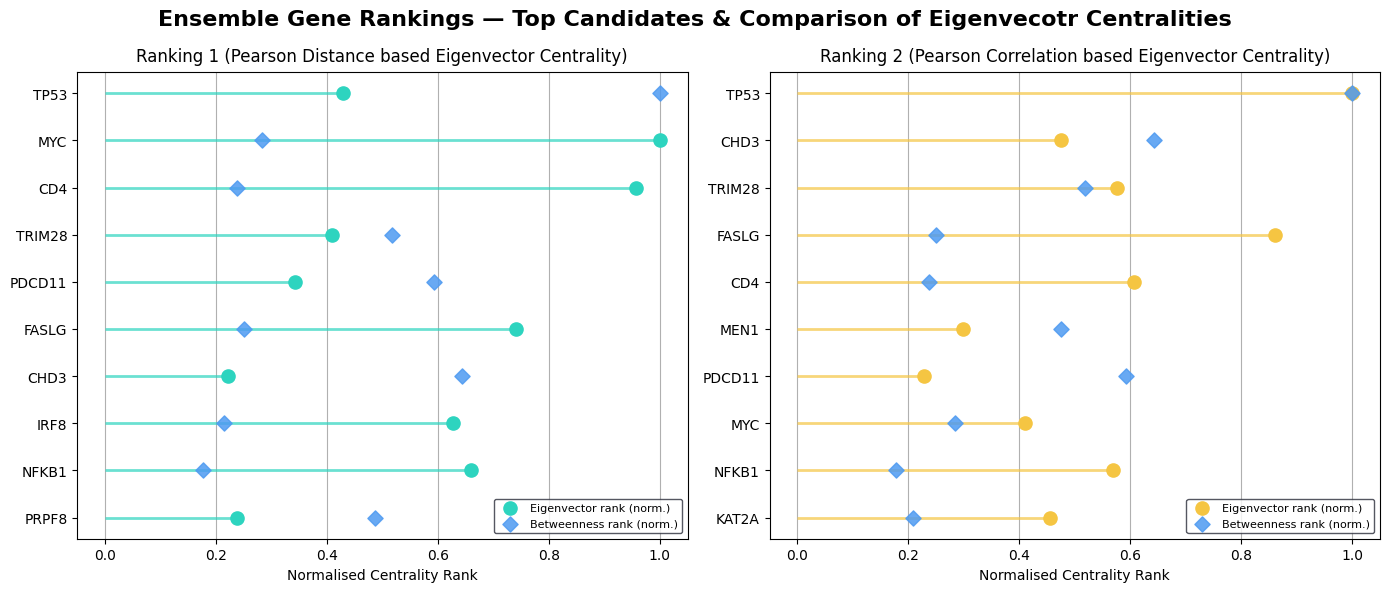

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle("Ensemble Gene Rankings — Top Candidates & Comparison of Eigenvecotr Centralities", fontsize=16, fontweight="bold")

# Zip together the axes, the top 10 genes from both ensemble rankings, their respective labels and colors for plotting to create 2 subplots
for ax, df, label, color in zip(
    axes,
    [distance_ensemble_ranking_df.head(10), correlation_ensemble_ranking_df.head(10)],
    ["Ranking 1 (Pearson Distance based Eigenvector Centrality)", "Ranking 2 (Pearson Correlation based Eigenvector Centrality)"],
    [PALETTE["teal"], PALETTE["gold"]],
):
    sub = df.copy()
    y   = sub.index # The index has the gene names

    ax.hlines(y, 0, sub["Eigenvector_rank_normalized"], color=color, linewidth=2, alpha=0.7) # Draw horizontal lines from 0 to the Eigenvector rank for each gene
    # Place the points for both Eigenvector and Betweenness centrality ranks on top of the lines
    ax.scatter(sub["Eigenvector_rank_normalized"], y, color=color, s=90, zorder=5,
                label="Eigenvector rank (norm.)")
    ax.scatter(sub["Betweenness_rank_normalized"],  y, color=PALETTE["GO"], s=60,
                marker="D", zorder=5, label="Betweenness rank (norm.)", alpha=0.85)

    ax.set_yticks(list(y))
    ax.set_yticklabels(sub.index, fontsize=10)
    ax.invert_yaxis() # So the best ranked genes are on top
    ax.set_xlabel("Normalised Centrality Rank")
    ax.set_title(label, fontsize=12, pad=8)
    ax.grid(axis="x")
    ax.legend(fontsize=8, loc="lower right",
                edgecolor="#2A2D3A")

fig.tight_layout()
plt.show()

### Enrichment Plots

The GSEAPY's plots just straight up don't work like they are supposed to, so we will have to do it via pyplot

A good choice here is a Volacno plot with adjusted p-value and Overlap Count on the x- and y-axes. To compare both GO vs KEGG and Correlation vs Distance Centrality, we will do a 2x2 subplot

- GO will be at the top, KEGG at the bottom. 
- Distance will be left, while correlation will be right.

We will first create 4 different DataFrames, for GO and KEGG, both with Distance and correlation measures

In [114]:
correlation_kegg_enrichment = final_correlation_enrichment_df[final_correlation_enrichment_df["Gene_set"] == "kegg.gmt"]
distance_kegg_enrichment = final_distance_enrichment_df[final_distance_enrichment_df["Gene_set"] == "kegg.gmt"]

correlation_go_enrichment = final_correlation_enrichment_df[final_correlation_enrichment_df["Gene_set"] == "go.gmt"]
distance_go_enrichment = final_distance_enrichment_df[final_distance_enrichment_df["Gene_set"] == "go.gmt"]

In [140]:
import numpy as np

COLORS = {
    "GO_dist":   "#4E9AF1",
    "GO_corr":   "#2DD4BF",
    "KEGG_dist": "#F17F4E",
    "KEGG_corr": "#F5C542"
}

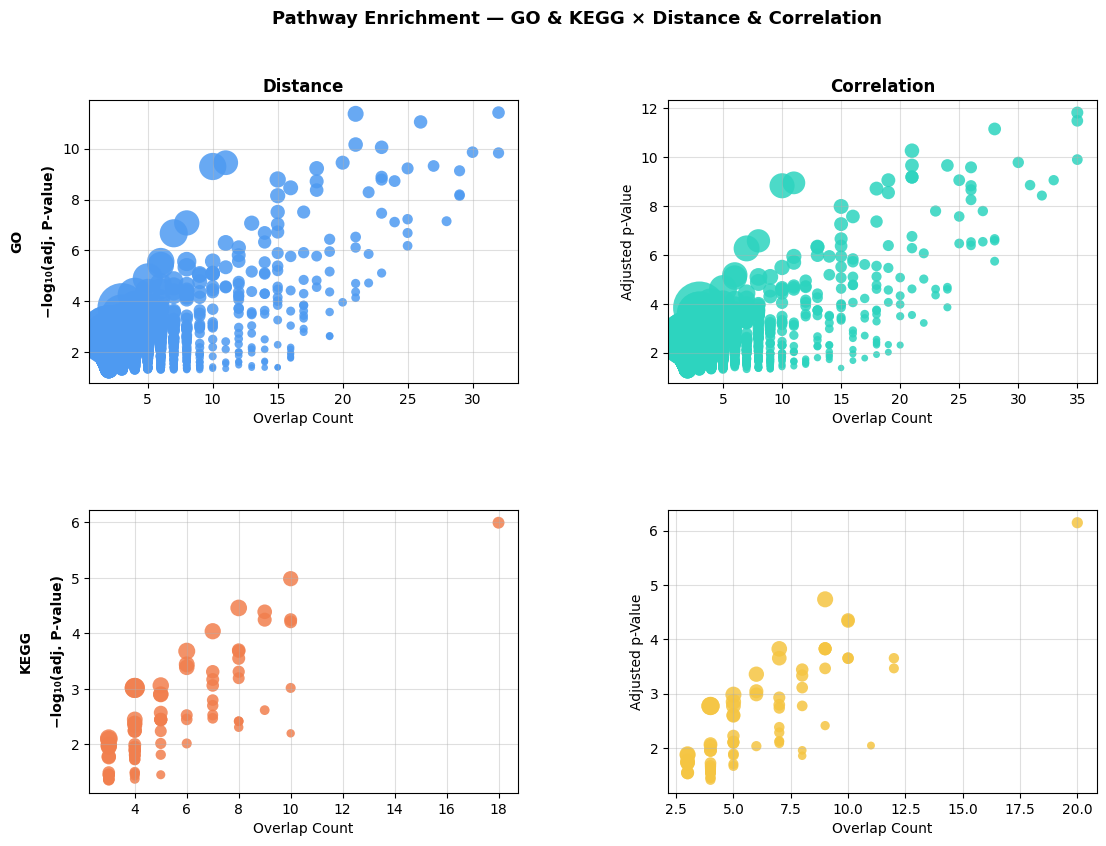

In [142]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                            gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.suptitle("Pathway Enrichment — GO & KEGG × Distance & Correlation",
                fontsize=13, fontweight="bold")

panels = [
    (distance_go_enrichment,   0, 0, "GO_dist",   "Distance",    "GO"),
    (correlation_go_enrichment,   0, 1, "GO_corr",   "Correlation", "GO"),
    (distance_kegg_enrichment, 1, 0, "KEGG_dist", "Distance",    "KEGG"),
    (correlation_kegg_enrichment, 1, 1, "KEGG_corr", "Correlation", "KEGG"),
]

for df, row, col, ckey, col_title, row_title in panels:
    ax  = axes[row, col]
    df  = df.copy()
    # Transform the adjusted p-value to -log10 for better visualization
    df["Adjusted P-value"] = -np.log10(df["Adjusted P-value"])

    # Significant points
    ax.scatter(x=df["Overlap_count"], y=df["Adjusted P-value"],
                s=df["Odds Ratio"] * 10,
                color=COLORS[ckey], alpha=0.85, edgecolors="none")

    ax.set_xlabel("Overlap Count")
    ax.set_ylabel("Adjusted p-Value")

    ax.grid(True, alpha=0.4)

    if row == 0:
        ax.set_title(col_title, fontweight="bold")
    if col == 0:
        ax.set_ylabel(f"{row_title}\n\n−log₁₀(adj. P-value)", fontweight="bold")


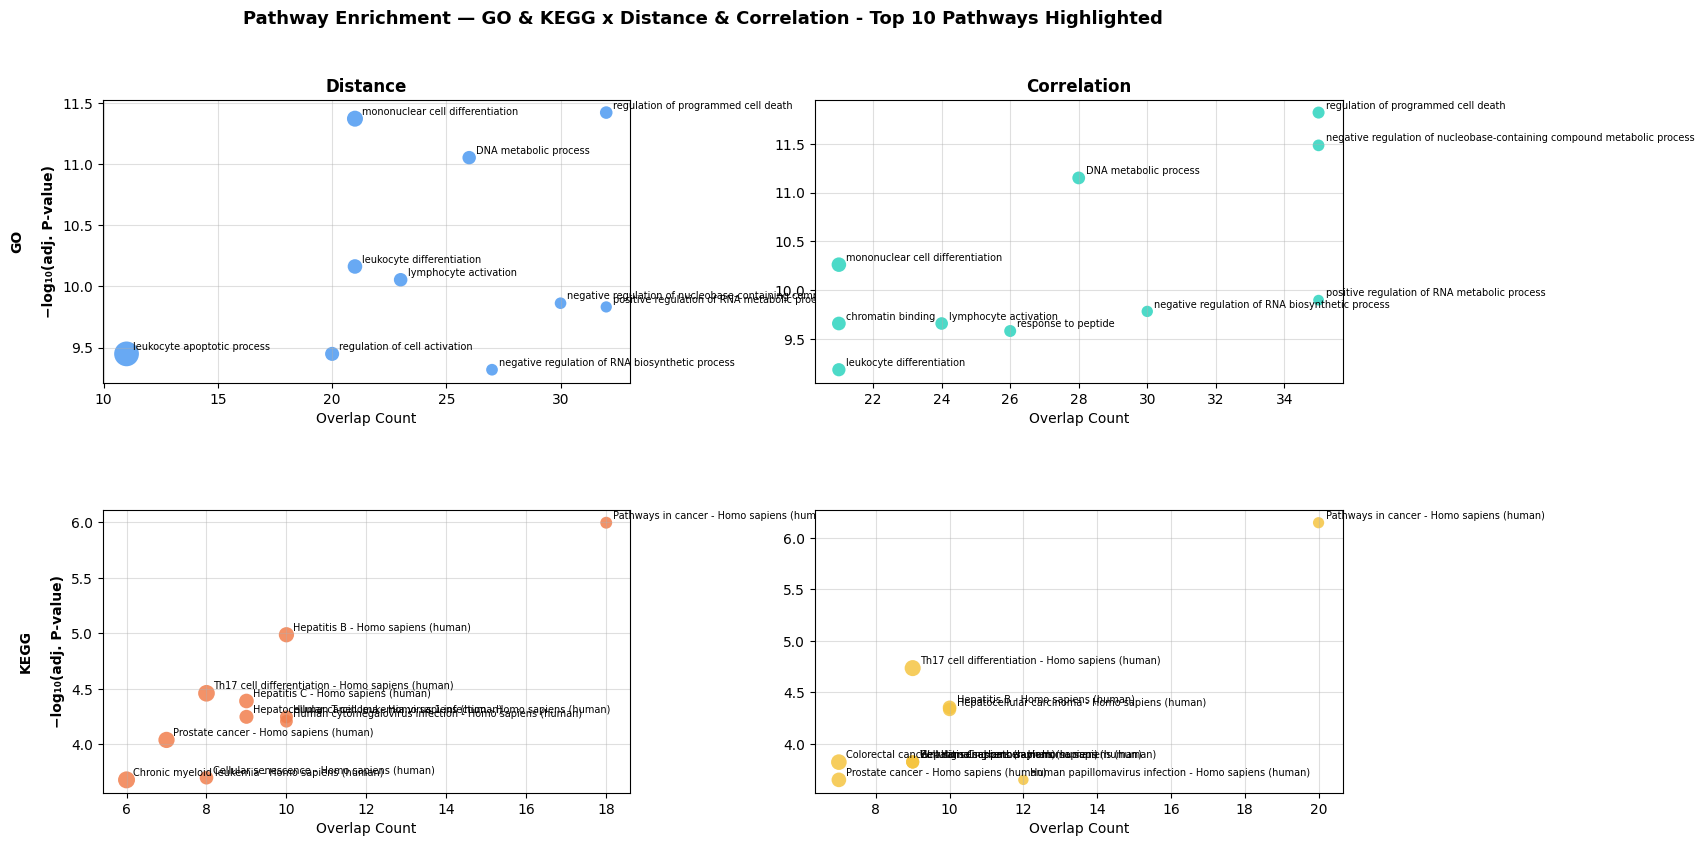

In [148]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9),
                            gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.suptitle("Pathway Enrichment — GO & KEGG x Distance & Correlation - Top 10 Pathways Highlighted",
                fontsize=13, fontweight="bold")

panels = [
    (distance_go_enrichment,   0, 0, "GO_dist",   "Distance",    "GO"),
    (correlation_go_enrichment,   0, 1, "GO_corr",   "Correlation", "GO"),
    (distance_kegg_enrichment, 1, 0, "KEGG_dist", "Distance",    "KEGG"),
    (correlation_kegg_enrichment, 1, 1, "KEGG_corr", "Correlation", "KEGG"),
]

for df, row, col, ckey, col_title, row_title in panels:
    ax  = axes[row, col]
    df  = df.copy().head(10) # Only show the top 10 for better visualization
    # Transform the adjusted p-value to -log10 for better visualization
    df["Adjusted P-value"] = -np.log10(df["Adjusted P-value"])

    # Significant points
    ax.scatter(x=df["Overlap_count"], y=df["Adjusted P-value"],
                s=df["Odds Ratio"] * 10,
                color=COLORS[ckey], alpha=0.85, edgecolors="none")

    # Labels for top-N most significant
    for _, pt in df.nlargest(10, "Adjusted P-value").iterrows():
        label = str(pt["Pathway_Descripton"])
        ax.annotate(label, xy=(pt["Overlap_count"], pt["Adjusted P-value"]),
                    xytext=(5, 3), textcoords="offset points", fontsize=7)

    ax.set_xlabel("Overlap Count")

    ax.grid(True, alpha=0.4)

    # Only set the titles and y-labels for the leftmost and topmost plots to avoid redundancy
    if row == 0:
        ax.set_title(col_title, fontweight="bold")
    if col == 0:
        ax.set_ylabel(f"{row_title}\n\n−log₁₀(adj. P-value)", fontweight="bold")
